In [ ]:
#Downloading Dependencies
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Reading & Feature Engineering Data
df = pd.read_csv("cricket.csv" , low_memory=False)

# print(df)
# print(df.columns)

df['date'] = pd.to_datetime(df['date'])

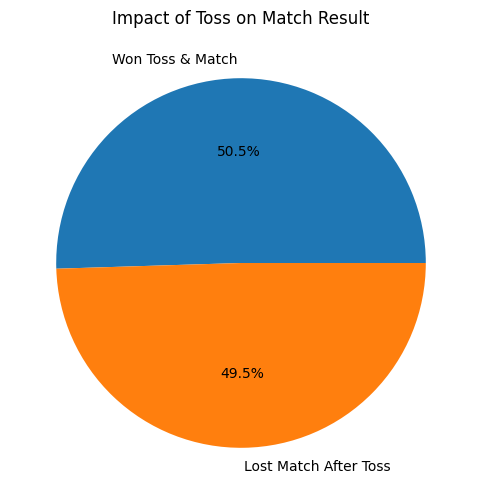


INSIGHT: If percentages are close to 50-50,
toss does NOT strongly decide matches.
If winning toss percentage > 60%,
then toss has major influence.



In [3]:
# ==========================================
# TOSS IMPACT ANALYSIS
# ==========================================

# Unique match-level data
matches = df[[
    "match_id",
    "toss_winner",
    "winner"
]].drop_duplicates()

matches["toss_match_win"] = (
    matches["toss_winner"] == matches["winner"]
)

toss_result = matches["toss_match_win"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    toss_result,
    labels=["Won Toss & Match", "Lost Match After Toss"],
    autopct="%1.1f%%"
)

plt.title("Impact of Toss on Match Result")
plt.show()


print("""
INSIGHT: If percentages are close to 50-50,
toss does NOT strongly decide matches.
If winning toss percentage > 60%,
then toss has major influence.
""")

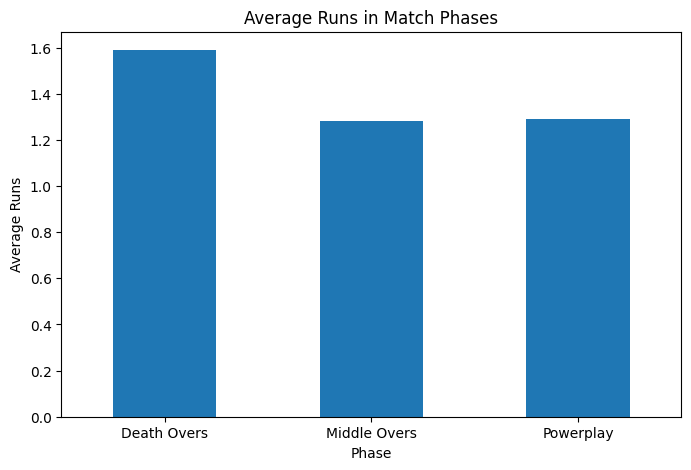


INSIGHT:
- Powerplay shows aggressive batting.
- Middle overs usually stabilize innings.
- Death overs often have highest scoring rate.

<--------------------------------------------------------------------------->



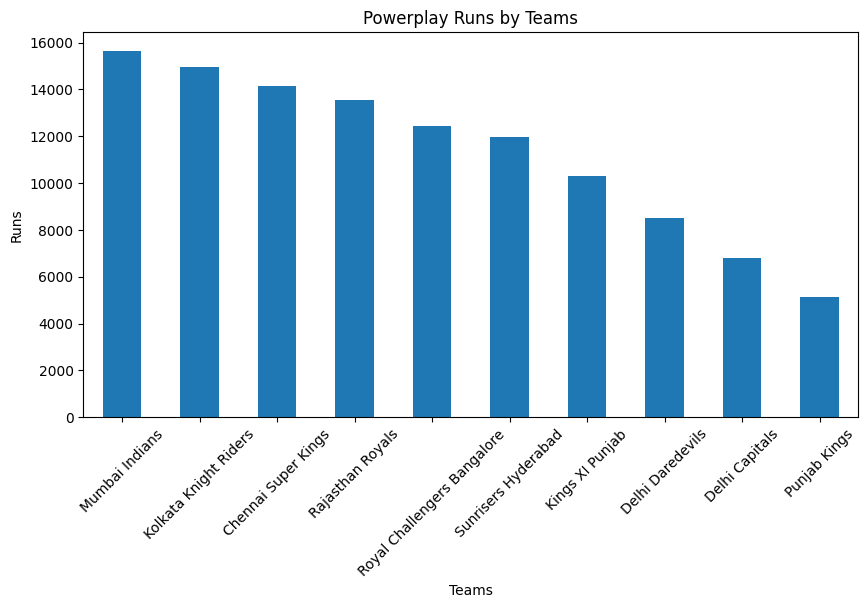


Insights : 
- Mumbai Indians and KKR scored the highest powerplay runs, showing aggressive opening strategies.
- Teams with strong powerplay performance gain early momentum and higher run rates.
- Punjab Kings and Delhi Capitals had lower powerplay scores, indicating slower starts.

<--------------------------------------------------------------------------->



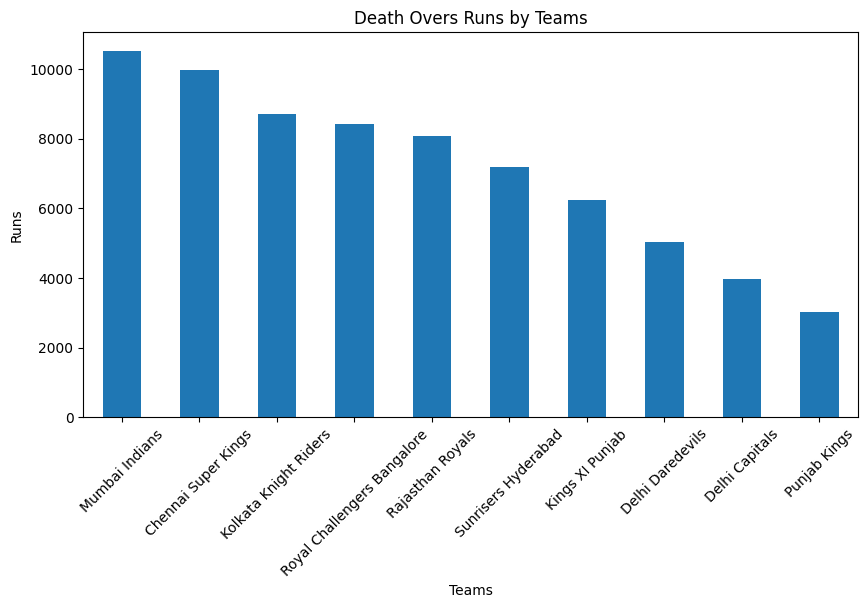


Insights : 
- Mumbai Indians dominated death overs, proving strong finishing ability in final overs.
- CSK and KKR also performed well due to powerful middle and lower-order batting.
- Teams with high death-over scoring usually have better chances of winning close matches.



In [4]:
# ==========================================
# POWERPLAY vs MIDDLE vs DEATH OVERS
# ==========================================

def phase(over):
    if over <= 5:
        return "Powerplay"
    elif over <= 14:
        return "Middle Overs"
    else:
        return "Death Overs"

df["phase"] = df["over"].apply(phase)

phase_runs = (
    df.groupby("phase")["runs_total"]
    .mean()
)

plt.figure(figsize=(8,5))

phase_runs.plot(kind="bar")

plt.title("Average Runs in Match Phases")
plt.ylabel("Average Runs")
plt.xlabel("Phase")
plt.xticks(rotation=0)

plt.show()


print("""
INSIGHT:
- Powerplay shows aggressive batting.
- Middle overs usually stabilize innings.
- Death overs often have highest scoring rate.
""")

print("<--------------------------------------------------------------------------->\n")

#Powerplay Runs By Team
powerplay = df[df['over'] <= 6]
powerplay_runs = powerplay.groupby('batting_team')['runs_total'].sum().sort_values(ascending=False).head(10)

powerplay_runs.plot(kind='bar', figsize=(10,5))
plt.title('Powerplay Runs by Teams')
plt.xlabel('Teams')
plt.ylabel('Runs')
plt.xticks(rotation=45)
plt.show()

print("""
Insights : 
- Mumbai Indians and KKR scored the highest powerplay runs, showing aggressive opening strategies.
- Teams with strong powerplay performance gain early momentum and higher run rates.
- Punjab Kings and Delhi Capitals had lower powerplay scores, indicating slower starts.
""")

print("<--------------------------------------------------------------------------->\n")

#Death Over Runs By Team
death = df[df['over'] >= 16]
death_runs = death.groupby('batting_team')['runs_total'].sum().sort_values(ascending=False).head(10)

death_runs.plot(kind='bar', figsize=(10,5))
plt.title('Death Overs Runs by Teams')
plt.xlabel('Teams')
plt.ylabel('Runs')
plt.xticks(rotation=45)
plt.show()

print("""
Insights : 
- Mumbai Indians dominated death overs, proving strong finishing ability in final overs.
- CSK and KKR also performed well due to powerful middle and lower-order batting.
- Teams with high death-over scoring usually have better chances of winning close matches.
""")


Top Batter in Every IPL Season

Season      Top Batter  Runs
  2007        SE Marsh   616
  2009       ML Hayden   572
  2009    SR Tendulkar   618
  2011        CH Gayle   608
  2012        CH Gayle   733
  2013      MEK Hussey   733
  2014      RV Uthappa   660
  2015       DA Warner   562
  2016         V Kohli   973
  2017       DA Warner   641
  2018   KS Williamson   735
  2019       DA Warner   692
  2020        KL Rahul   676
  2021      RD Gaikwad   635
  2022      JC Buttler   863
  2023    Shubman Gill   890
  2024         V Kohli   741
  2025 B Sai Sudharsan   759
  2026       H Klaasen   494
<--------------------------------------------------------------------------->



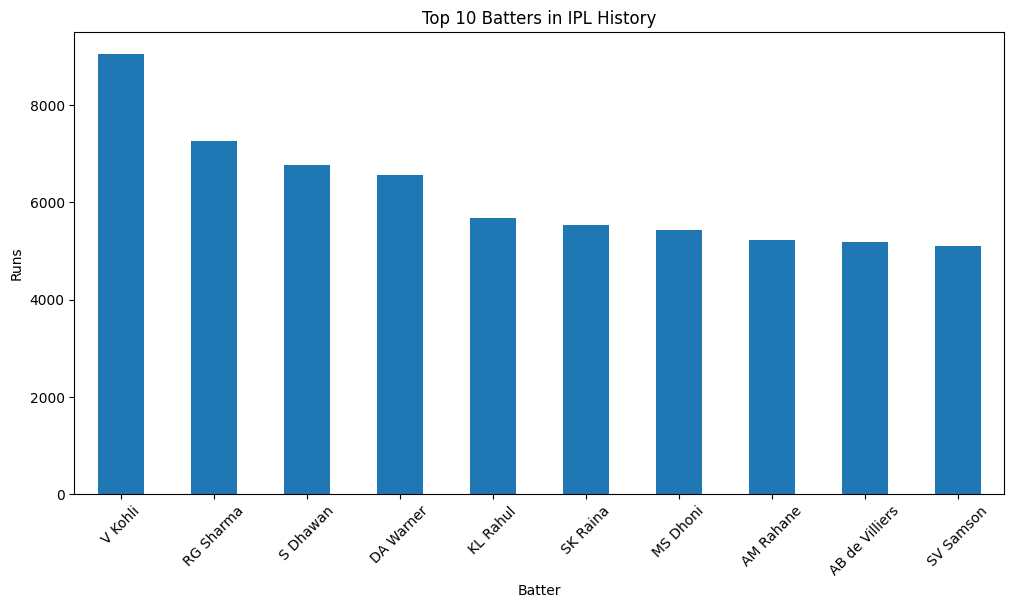

In [5]:
# ==========================================
# TOP BATTER IN EVERY IPL SEASON
# ==========================================

df.columns = df.columns.str.strip()

# Total runs scored by each batter per season
season_batter_runs = (
    df.groupby(["season", "batter"])["runs_batter"]
    .sum()
    .reset_index()
)

# Get highest run scorer in each season
top_batter_each_season = season_batter_runs.loc[
    season_batter_runs.groupby("season")["runs_batter"].idxmax()
]

# Rename columns
top_batter_each_season = top_batter_each_season.rename(columns={
    "season": "Season",
    "batter": "Top Batter",
    "runs_batter": "Runs"
})

# Convert season
top_batter_each_season["Season"] = (
    top_batter_each_season["Season"]
    .astype(str)
    .str.split("/")
    .str[0]
)

# Sort by season
top_batter_each_season = top_batter_each_season.sort_values("Season")

# Display Result
print("\nTop Batter in Every IPL Season\n")

print(top_batter_each_season.to_string(index=False))

# Save Result (Optional)
# top_batter_each_season.to_csv(
#     "top_batter_each_season.csv",
#     index=False
# )

# print("\nCSV file saved successfully!")


print("<--------------------------------------------------------------------------->\n")


# ==========================================
# TOP BATTERS ACROSS SEASONS
# ==========================================

import matplotlib.pyplot as plt

batters = (
    df.groupby("batter")["runs_batter"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)


plt.figure(figsize=(12,6))

batters.plot(
    kind="bar",
    title="Top 10 Batters in IPL History"
)

plt.ylabel("Runs")
plt.xlabel("Batter")
plt.xticks(rotation=45)

plt.show()


Top Bowler in Every IPL Season

Season        Top Bowler  Wickets
  2007     Sohail Tanvir       24
  2009          RP Singh       26
  2009           PP Ojha       22
  2011        SL Malinga       30
  2012          M Morkel       30
  2013          DJ Bravo       34
  2014         MM Sharma       26
  2015          DJ Bravo       28
  2016           B Kumar       24
  2017           B Kumar       28
  2018            AJ Tye       28
  2019          K Rabada       29
  2020          K Rabada       32
  2021          HV Patel       35
  2022         YS Chahal       29
  2023         MM Sharma       31
  2024          HV Patel       30
  2025 M Prasidh Krishna       26
  2026          A Kamboj       18

<--------------------------------------------------------------------------->



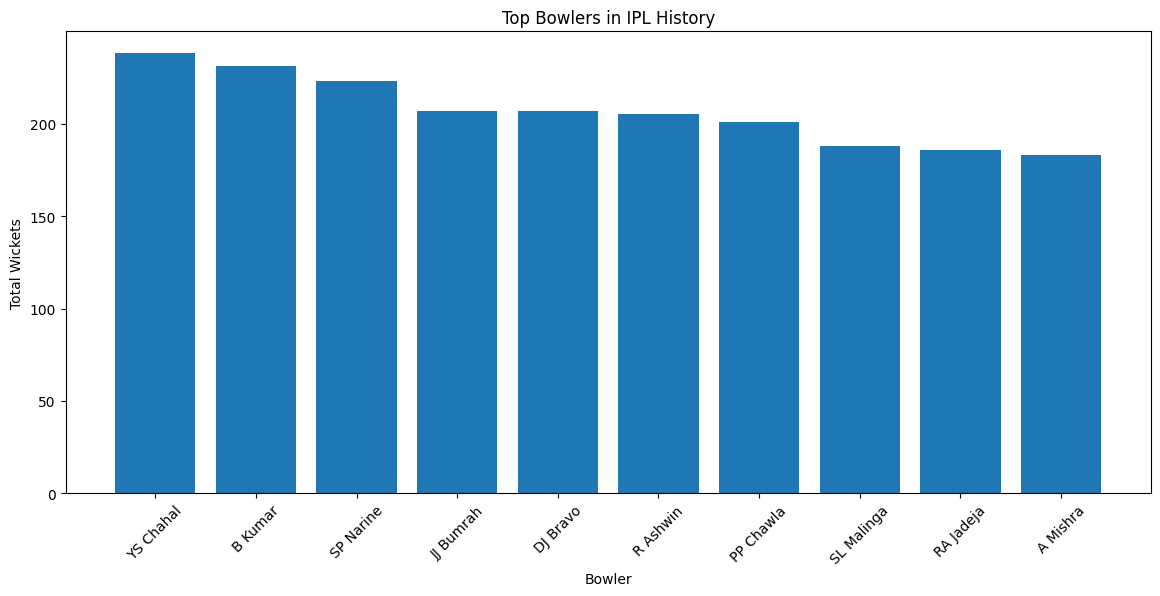

In [6]:
# ==========================================
# TOP BOWLER IN EVERY IPL SEASON
# ==========================================

# Remove rows without wicket
wickets_df = df.dropna(subset=["wicket_player_out"])

# Count wickets season-wise
season_bowler_wickets = (
    wickets_df.groupby(["season", "bowler"])
    .size()
    .reset_index(name="Wickets")
)

# Get highest wicket taker each season
top_bowler_each_season = season_bowler_wickets.loc[
    season_bowler_wickets.groupby("season")["Wickets"].idxmax()
]

# Rename columns
top_bowler_each_season = top_bowler_each_season.rename(columns={
    "season": "Season",
    "bowler": "Top Bowler"
})

# Convert season like 2007/08 -> 2007
top_bowler_each_season["Season"] = (
    top_bowler_each_season["Season"]
    .astype(str)
    .str.split("/")
    .str[0]
)

# Sort by season
top_bowler_each_season = top_bowler_each_season.sort_values("Season")


# Count wickets for each bowler
top_bowlers = (
    wickets_df.groupby("bowler")
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="Wickets")
)

# Rename columns
top_bowlers.columns = ["Top Bowler", "Wickets"]

print("\nTop Bowler in Every IPL Season\n")

print(top_bowler_each_season.to_string(index=False))

print("\n<--------------------------------------------------------------------------->\n")

# ==========================================
# TOP BOWLERS IN IPL HISTORY (GRAPH)
# ==========================================

plt.figure(figsize=(14,6))

plt.bar(
    top_bowlers["Top Bowler"],
    top_bowlers["Wickets"]
)

plt.title("Top Bowlers in IPL History")
plt.xlabel("Bowler")
plt.ylabel("Total Wickets")

plt.xticks(rotation=45)

plt.show()


Top 10 Batters With Most Sixes

        Batter  Total Sixes
      CH Gayle          359
     RG Sharma          318
       V Kohli          307
      MS Dhoni          264
AB de Villiers          253
     SV Samson          240
     DA Warner          236
      KL Rahul          232
    KA Pollard          224
    AD Russell          223

<--------------------------------------------------------------------------->



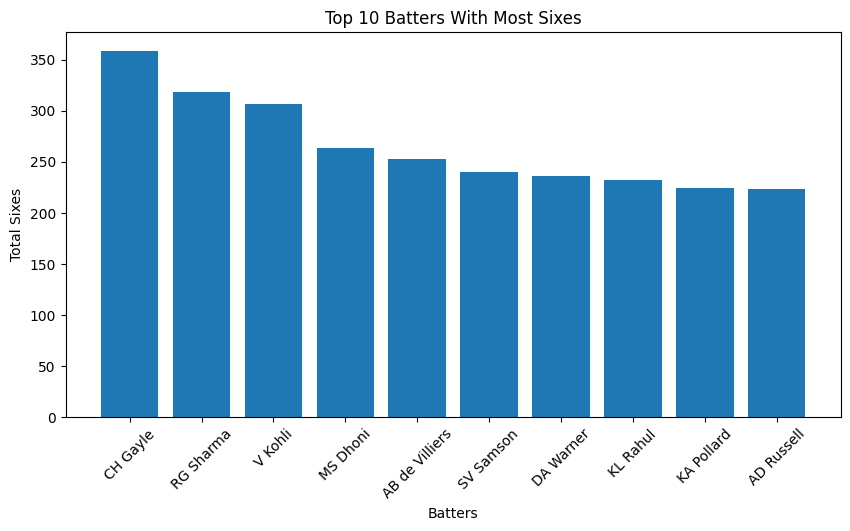

In [7]:
# ==========================================
# TOP 10 BATTERS WITH MOST SIXES
# ==========================================

sixes = (
    df[df['runs_batter'] == 6]
    .groupby('batter')['runs_batter']
    .count()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# Rename columns
sixes.columns = ['Batter', 'Total Sixes']

# Display Result
print("\nTop 10 Batters With Most Sixes\n")

print(sixes.to_string(index=False))

print("\n<--------------------------------------------------------------------------->\n")

# Graph
plt.figure(figsize=(10,5))

plt.bar(sixes['Batter'], sixes['Total Sixes'])

plt.title('Top 10 Batters With Most Sixes')
plt.xlabel('Batters')
plt.ylabel('Total Sixes')

plt.xticks(rotation=45)

plt.show()


Top 10 Batters With Most Fours

    Batter  Total Fours
   V Kohli          816
  S Dhawan          768
 DA Warner          663
 RG Sharma          659
 AM Rahane          527
  SK Raina          506
  KL Rahul          497
 G Gambhir          492
RV Uthappa          481
  SA Yadav          477

<--------------------------------------------------------------------------->



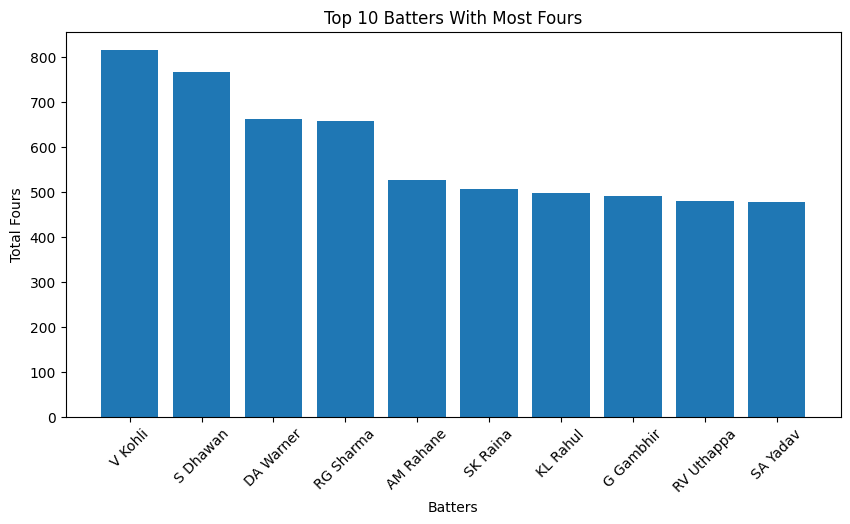

In [8]:
# ==========================================
# TOP 10 BATTERS WITH MOST FOURS
# ==========================================

fours = (
    df[df['runs_batter'] == 4]
    .groupby('batter')['runs_batter']
    .count()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# Rename columns
fours.columns = ['Batter', 'Total Fours']

# Display Result
print("\nTop 10 Batters With Most Fours\n")

print(fours.to_string(index=False))

print("\n<--------------------------------------------------------------------------->\n")

# Graph
plt.figure(figsize=(10,5))

plt.bar(fours['Batter'], fours['Total Fours'])

plt.title('Top 10 Batters With Most Fours')
plt.xlabel('Batters')
plt.ylabel('Total Fours')

plt.xticks(rotation=45)

plt.show()

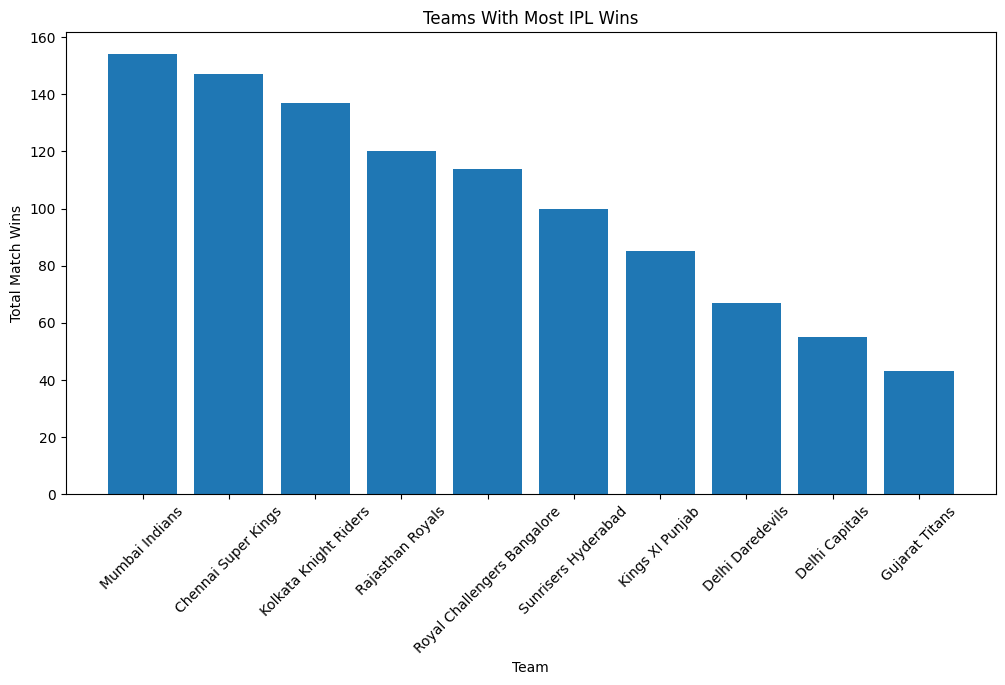

In [9]:
# ==========================================
# TEAMS WITH MOST IPL WINS
# ==========================================

# Get unique match results
matches = df[["match_id", "winner"]].drop_duplicates()

# Count wins for each team
team_wins = (
    matches["winner"]
    .value_counts()
    .head(10)
    .reset_index()
)

# Rename columns
team_wins.columns = ["Team", "Total Wins"]


# Plot graph
plt.figure(figsize=(12,6))

plt.bar(
    team_wins["Team"],
    team_wins["Total Wins"]
)

plt.title("Teams With Most IPL Wins")
plt.xlabel("Team")
plt.ylabel("Total Match Wins")

plt.xticks(rotation=45)


plt.show()


Top 10 Players With Most Player of the Match Awards

        Player  Total Awards
AB de Villiers            25
      CH Gayle            22
     RG Sharma            21
       V Kohli            20
     DA Warner            18
      MS Dhoni            18
      KL Rahul            17
     RA Jadeja            17
     SP Narine            17
    AD Russell            16

<--------------------------------------------------------------------------->



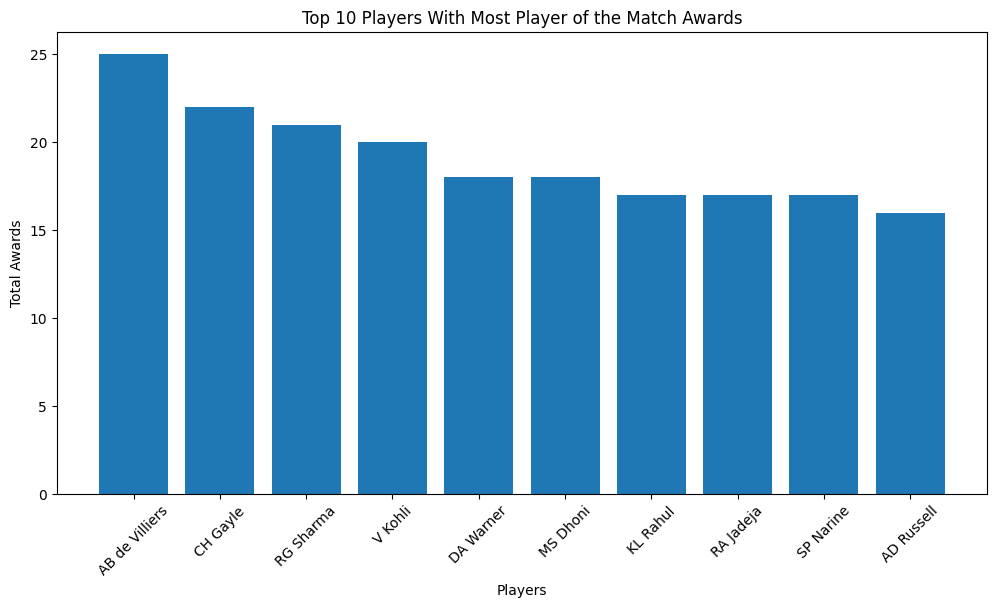

In [10]:
# ==========================================
# MOST PLAYER OF THE MATCH AWARDS
# ==========================================

# Get unique player of match records
pom = (
    df[['match_id', 'player_of_match']]
    .drop_duplicates()
)

# Count awards
pom = (
    pom['player_of_match']
    .value_counts()
    .head(10)
    .reset_index()
)

# Rename columns
pom.columns = ['Player', 'Total Awards']

# Display Result
print("\nTop 10 Players With Most Player of the Match Awards\n")

print(pom.to_string(index=False))

print("\n<--------------------------------------------------------------------------->\n")

# Plot graph
plt.figure(figsize=(12,6))

plt.bar(pom['Player'], pom['Total Awards'])

plt.title('Top 10 Players With Most Player of the Match Awards')
plt.xlabel('Players')
plt.ylabel('Total Awards')

plt.xticks(rotation=45)


plt.show()

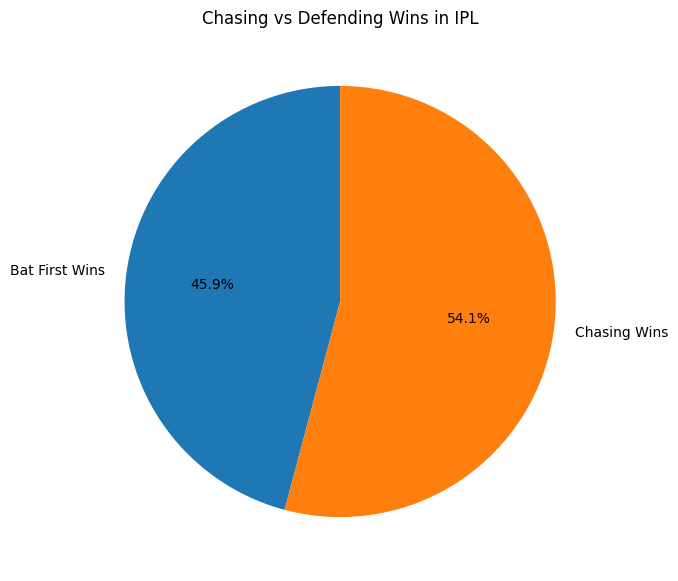


INSIGHTS:
 - More chasing wins indicate batting second
   is easier due to dew or pitch conditions.

- More defending wins show scoreboard pressure
   plays an important role in T20 cricket.

- Balanced results suggest both strategies
   are equally competitive in IPL matches.



In [11]:
# ==========================================
# 6. CHASING vs DEFENDING
# ==========================================


# Get unique match results
match_results = df[[
    "match_id",
    "win_by_runs",
    "win_by_wickets"
]].drop_duplicates()

# Count wins
bat_first = (match_results["win_by_runs"] > 0).sum()

chasing = (match_results["win_by_wickets"] > 0).sum()

# Data
labels = ["Bat First Wins", "Chasing Wins"]
sizes = [bat_first, chasing]

# Pie Chart
plt.figure(figsize=(7,7))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Chasing vs Defending Wins in IPL")

plt.show()

print("""
INSIGHTS:
 - More chasing wins indicate batting second
   is easier due to dew or pitch conditions.

- More defending wins show scoreboard pressure
   plays an important role in T20 cricket.

- Balanced results suggest both strategies
   are equally competitive in IPL matches.
""")

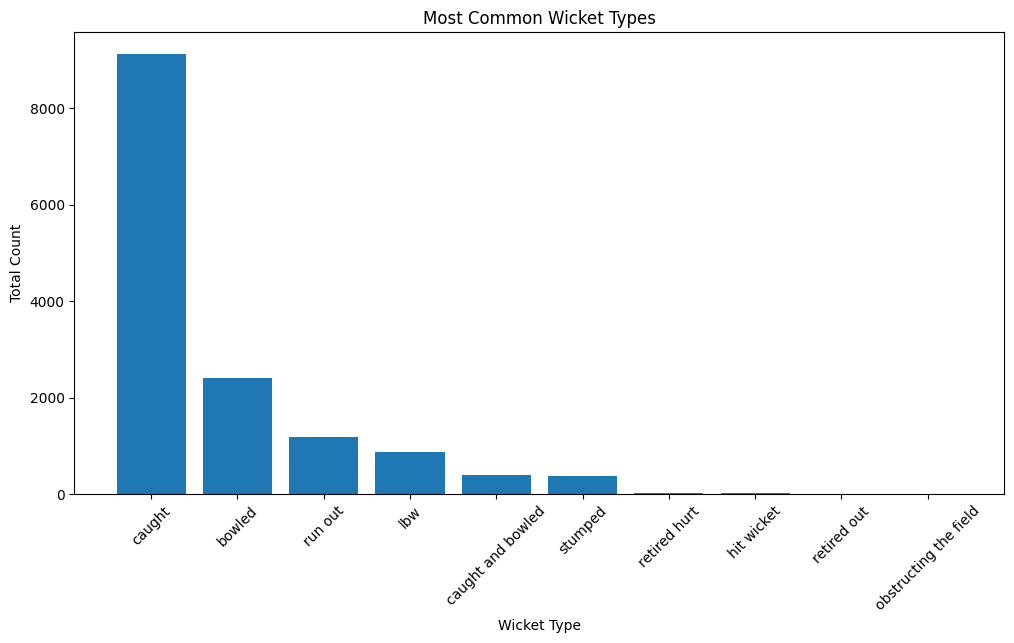


INSIGHTS:
1. Caught is the most common wicket type,
   showing fielding and pace bowling dominate IPL dismissals.

2. Bowled and LBW dismissals are also frequent,
   indicating strong line and length bowling strategies.

3. Run-outs and stumpings occur less often,
   usually depending on special match situations or fielding brilliance.



In [12]:
# ==========================================
# MOST COMMON WICKET TYPES
# ==========================================

# Count wicket types
wicket_types = (
    df['wicket_kind']
    .value_counts()
    .head(10)
    .reset_index()
)

# Rename columns
wicket_types.columns = ['Wicket Type', 'Count']


# Plot graph
plt.figure(figsize=(12,6))

plt.bar(
    wicket_types['Wicket Type'],
    wicket_types['Count']
)

plt.title('Most Common Wicket Types')
plt.xlabel('Wicket Type')
plt.ylabel('Total Count')

plt.xticks(rotation=45)


plt.show()

print("""
INSIGHTS:
1. Caught is the most common wicket type,
   showing fielding and pace bowling dominate IPL dismissals.

2. Bowled and LBW dismissals are also frequent,
   indicating strong line and length bowling strategies.

3. Run-outs and stumpings occur less often,
   usually depending on special match situations or fielding brilliance.
""")


Top Venues Hosting IPL Matches : For Buisness Purpose

                                    Venue  Matches Hosted
                             Eden Gardens              77
                         Wankhede Stadium              73
                    M Chinnaswamy Stadium              65
                         Feroz Shah Kotla              60
                 Wankhede Stadium, Mumbai              58
Rajiv Gandhi International Stadium, Uppal              49
          MA Chidambaram Stadium, Chepauk              48
                   Sawai Mansingh Stadium              47
      Dubai International Cricket Stadium              46
 MA Chidambaram Stadium, Chepauk, Chennai              39

<--------------------------------------------------------------------------->



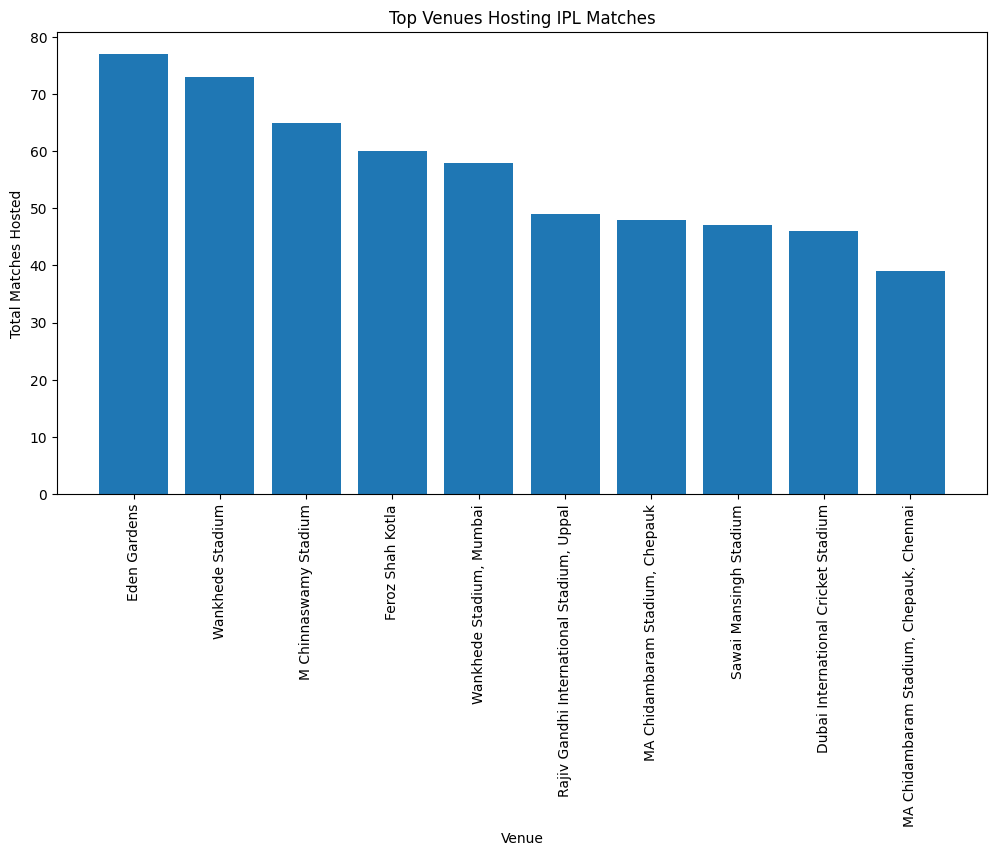

In [13]:
# ==========================================
# TOP VENUES HOSTING IPL MATCHES
# ==========================================

# Count matches hosted by each venue
venues = (
    df[['match_id', 'venue']]
    .drop_duplicates()
    ['venue']
    .value_counts()
    .head(10)
    .reset_index()
)

# Rename columns
venues.columns = ['Venue', 'Matches Hosted']

# Display Result
print("\nTop Venues Hosting IPL Matches : For Buisness Purpose\n")

print(venues.to_string(index=False))

print("\n<--------------------------------------------------------------------------->\n")

# Plot graph
plt.figure(figsize=(12,6))

plt.bar(
    venues['Venue'],
    venues['Matches Hosted']
)

plt.title('Top Venues Hosting IPL Matches')
plt.xlabel('Venue')
plt.ylabel('Total Matches Hosted')

plt.xticks(rotation=90)


plt.show()


TEAM-WISE LUCKY VENUES

                       Team                                                           Lucky Venue  Wins
        Chennai Super Kings                                       MA Chidambaram Stadium, Chepauk    33
            Deccan Chargers                                                      Barabati Stadium     3
             Delhi Capitals                                           Arun Jaitley Stadium, Delhi     7
           Delhi Daredevils                                                      Feroz Shah Kotla    23
              Gujarat Lions                                Saurashtra Cricket Association Stadium     3
             Gujarat Titans                                      Narendra Modi Stadium, Ahmedabad    16
            Kings XI Punjab                            Punjab Cricket Association Stadium, Mohali    18
       Kochi Tuskers Kerala                                                         Nehru Stadium     2
      Kolkata Knight Riders            

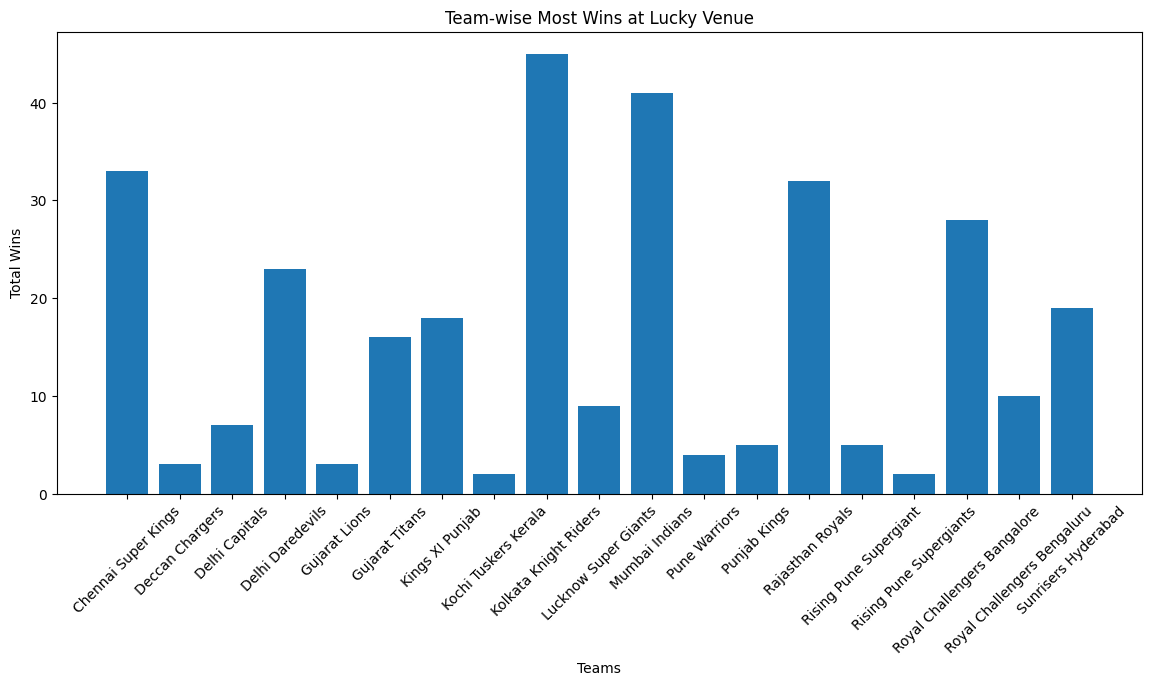


TEAM-WISE UNLUCKY VENUES

                       Team                                                         Unlucky Venue  Losses
        Chennai Super Kings                                       MA Chidambaram Stadium, Chepauk      14
            Deccan Chargers                             Rajiv Gandhi International Stadium, Uppal      15
             Delhi Capitals                                           Arun Jaitley Stadium, Delhi      15
           Delhi Daredevils                                                      Feroz Shah Kotla      33
              Gujarat Lions                                Saurashtra Cricket Association Stadium       7
             Gujarat Titans                                      Narendra Modi Stadium, Ahmedabad      12
            Kings XI Punjab                            Punjab Cricket Association Stadium, Mohali      17
       Kochi Tuskers Kerala                                                         Nehru Stadium       3
      Kolkata Knigh

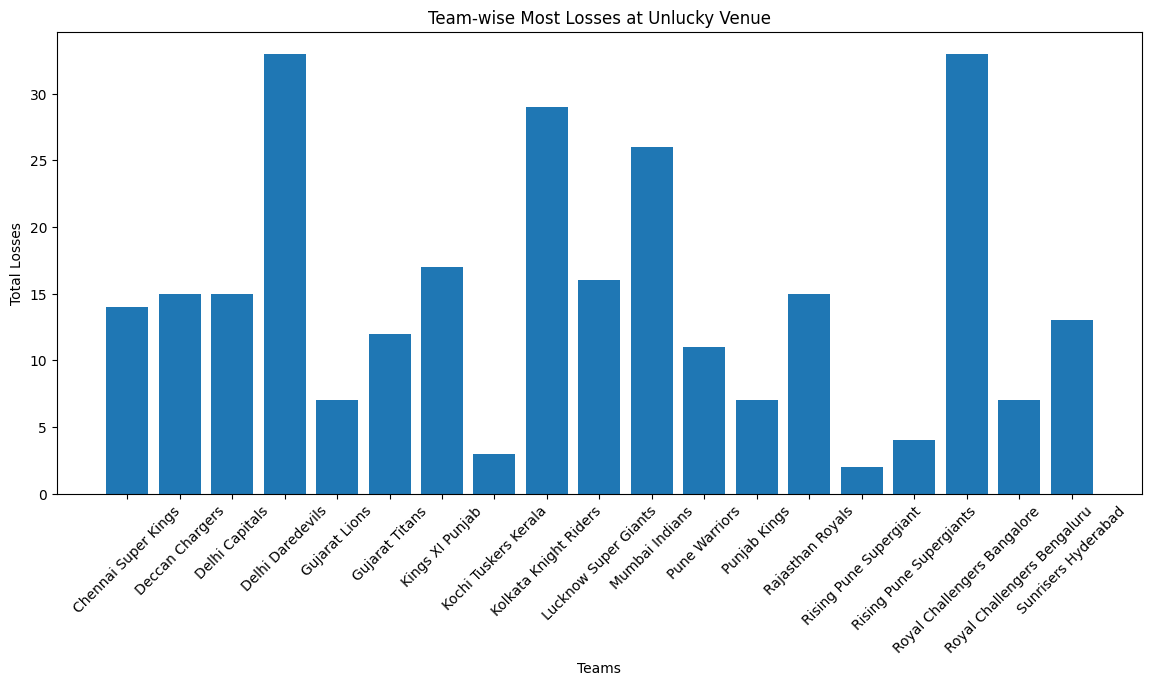

In [14]:
# ==========================================
# TEAM-WISE LUCKY & UNLUCKY VENUES
# ==========================================

# Get unique match records
matches = df[[
    'match_id',
    'venue',
    'team1',
    'team2',
    'winner'
]].drop_duplicates()

# Create separate team records
team1_df = matches[['match_id', 'venue', 'team1', 'winner']].copy()
team1_df.columns = ['match_id', 'venue', 'team', 'winner']

team2_df = matches[['match_id', 'venue', 'team2', 'winner']].copy()
team2_df.columns = ['match_id', 'venue', 'team', 'winner']

# Combine both teams
all_teams = pd.concat([team1_df, team2_df])

# Win/Loss Result
all_teams['Result'] = all_teams.apply(
    lambda x: 'Win' if x['team'] == x['winner'] else 'Loss',
    axis=1
)

# ==========================================
# LUCKY VENUE (MOST WINS)
# ==========================================

wins = (
    all_teams[all_teams['Result'] == 'Win']
    .groupby(['team', 'venue'])
    .size()
    .reset_index(name='Wins')
)

lucky_venue = wins.loc[
    wins.groupby('team')['Wins'].idxmax()
]

lucky_venue = lucky_venue.rename(columns={
    'team': 'Team',
    'venue': 'Lucky Venue'
})

print("\nTEAM-WISE LUCKY VENUES\n")

print(lucky_venue.to_string(index=False))

print("\n<--------------------------------------------------------------------------->\n")

# Lucky Venue Graph
plt.figure(figsize=(14,6))

plt.bar(
    lucky_venue['Team'],
    lucky_venue['Wins']
)

plt.title('Team-wise Most Wins at Lucky Venue')
plt.xlabel('Teams')
plt.ylabel('Total Wins')

plt.xticks(rotation=45)

plt.show()

# ==========================================
# UNLUCKY VENUE (MOST LOSSES)
# ==========================================

losses = (
    all_teams[all_teams['Result'] == 'Loss']
    .groupby(['team', 'venue'])
    .size()
    .reset_index(name='Losses')
)

unlucky_venue = losses.loc[
    losses.groupby('team')['Losses'].idxmax()
]

unlucky_venue = unlucky_venue.rename(columns={
    'team': 'Team',
    'venue': 'Unlucky Venue'
})

print("\nTEAM-WISE UNLUCKY VENUES\n")

print(unlucky_venue.to_string(index=False))

print("\n<--------------------------------------------------------------------------->\n")

# Unlucky Venue Graph
plt.figure(figsize=(14,6))

plt.bar(
    unlucky_venue['Team'],
    unlucky_venue['Losses']
)

plt.title('Team-wise Most Losses at Unlucky Venue')
plt.xlabel('Teams')
plt.ylabel('Total Losses')

plt.xticks(rotation=45)


plt.show()